# **Assignment 2: Mastering Big Data Handling**

Group: Taktaulah

Dataset: [Amazon Product Dataset](https://www.kaggle.com/datasets/piyushjain16/amazon-product-data)

## **1. Environment Setup and Dataset Preparation**

In [24]:
import pandas as pd
import numpy as np
import os
from IPython.display import display
import psutil
import time
import csv
import threading
import seaborn as sns
import matplotlib.pyplot as plt
import time
import timeit
import threading
import tracemalloc
import gc

In [25]:
from google.colab import files
files.upload()

{}

In [26]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [27]:
!kaggle datasets download -d piyushjain16/amazon-product-data
!unzip amazon-product-data.zip

Dataset URL: https://www.kaggle.com/datasets/piyushjain16/amazon-product-data
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
amazon-product-data.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  amazon-product-data.zip
  inflating: dataset/train.csv       


In [28]:
!ls

amazon-product-data.zip   library_comparison_row_1.png	sample_data
chart_all_strategies.png  library_comparison_row_2.png
dataset			  product_amazon_data.csv


In [29]:
import os

# Move the file from the subfolder to the main folder
if os.path.exists("dataset/train.csv"):
    os.rename("dataset/train.csv", "product_amazon_data.csv")
    print("Success: File is now product_amazon_data.csv and ready to use!")

Success: File is now product_amazon_data.csv and ready to use!


## **2. Library Choices**

- Dask
- Polars

In [30]:
import dask.dataframe as dd
import polars as pl

## **3. Data Loading and Initial Inspection**

In [31]:
# Task 2: Load and Inspect Data
df_copy = pd.read_csv("product_amazon_data.csv", low_memory=False)
df = df_copy.copy()

# Display the first 5 rows
df.head()

,PRODUCT_ID,TITLE,BULLET_POINTS,DESCRIPTION,PRODUCT_TYPE_ID,PRODUCT_LENGTH
0,1925202,ArtzFolio Tulip Flowers Blackout Curtain for D...,[LUXURIOUS & APPEALING: Beautiful custom-made ...,NaN,1650,2125.980000
1,2673191,Marks & Spencer Girls' Pyjama Sets T86_2561C_N...,"[Harry Potter Hedwig Pyjamas (6-16 Yrs),100% c...",NaN,2755,393.700000
2,2765088,PRIKNIK Horn Red Electric Air Horn Compressor ...,"[Loud Dual Tone Trumpet Horn, Compatible With ...","Specifications: Color: Red, Material: Aluminiu...",7537,748.031495
3,1594019,ALISHAH Women's Cotton Ankle Length Leggings C...,[Made By 95%cotton and 5% Lycra which gives yo...,AISHAH Women's Lycra Cotton Ankel Leggings. Br...,2996,787.401574
4,283658,The United Empire Loyalists: A Chronicle of th...,NaN,NaN,6112,598.424000


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2249698 entries, 0 to 2249697
Data columns (total 6 columns):
 #   Column           Dtype  
---  ------           -----  
 0   PRODUCT_ID       int64  
 1   TITLE            object 
 2   BULLET_POINTS    object 
 3   DESCRIPTION      object 
 4   PRODUCT_TYPE_ID  int64  
 5   PRODUCT_LENGTH   float64
dtypes: float64(1), int64(2), object(3)
memory usage: 103.0+ MB


In [33]:
df.count()

,0
PRODUCT_ID,2249698
TITLE,2249685
BULLET_POINTS,1412332
DESCRIPTION,1092316
PRODUCT_TYPE_ID,2249698
PRODUCT_LENGTH,2249698


In [34]:
rows, cols = df.shape
print(f"Rows: {rows}, Columns: {cols}")

Rows: 2249698, Columns: 6


## **4. Big Data Handling Strategies**

### **4.1 Load Less Data**

In [35]:
def measure_performance(func, description="", *args, **kwargs):
    process = psutil.Process(os.getpid())

    cpu_percent = []
    done = [False]

    def track_cpu():
        while not done[0]:
            cpu_percent.append(process.cpu_percent(interval=0.1))

    cpu_thread = threading.Thread(target=track_cpu)
    cpu_thread.start()

    mem_before = process.memory_info().rss / 1024 / 1024  # MB
    start_time = time.time()

    try:
        result = func(*args, **kwargs)
        success = True
    except Exception as e:
        result = None
        success = False
        error_message = str(e)

    end_time = time.time()
    mem_after = process.memory_info().rss / 1024 / 1024  # MB

    done[0] = True
    cpu_thread.join()

    exec_time = round(end_time - start_time, 4)
    mem_diff_mb = mem_after - mem_before

    if isinstance(result, (pd.DataFrame)):
        num_records = len(result)
        throughput = round(num_records / exec_time, 2)
    else:
        throughput = None

    performance = {
        "Description": description,
        "Memory Used (MB)": round(mem_diff_mb, 2),
        "Execution Time (s)": exec_time,
        "Success": success,
        "Average CPU (%)": round(sum(cpu_percent) / len(cpu_percent), 2) if cpu_percent else 0.0,
        "Throughput (records/sec)": throughput
    }

    if not success:
        performance["Error"] = error_message

    return performance, result

def load_less_data_pandas(file_path):
    cols = ['PRODUCT_ID', 'TITLE', 'PRODUCT_TYPE_ID', 'PRODUCT_LENGTH']
    return pd.read_csv(file_path, usecols=cols)

file_path = "product_amazon_data.csv"

performance_less_data, df_less_data = measure_performance(
    load_less_data_pandas,
    description="Load Less Data with Pandas (Amazon Dataset)",
    file_path=file_path
)

display(pd.DataFrame([performance_less_data]))

,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Load Less Data with Pandas (Amazon Dataset),238.55,25.0889,True,91.37,89669.06


### **4.2 Chunking**

In [36]:
# Load Amazon Data using chunks
def load_with_chunking(file_path):
    chunks = []
    for chunk in pd.read_csv(file_path, chunksize=100000, low_memory=False):
        chunks.append(chunk)

    df = pd.concat(chunks, ignore_index=True)
    return df

performance_chunking, df_chunked = measure_performance(
    load_with_chunking,
    description="Chunked Load (Amazon Dataset)",
    file_path="product_amazon_data.csv"
)

# Display the results table
display(pd.DataFrame([performance_chunking]))

,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Chunked Load (Amazon Dataset),1624.5,33.7874,True,98.84,66583.93


### **4.3 Data Type Optimization**

In [37]:
def optimize_data_types(df_input):
    df_opt = df_input.copy()

    df_opt['PRODUCT_ID'] = pd.to_numeric(df_opt['PRODUCT_ID'], downcast='unsigned')
    df_opt['PRODUCT_TYPE_ID'] = pd.to_numeric(df_opt['PRODUCT_TYPE_ID'], downcast='unsigned')
    df_opt['PRODUCT_LENGTH'] = pd.to_numeric(df_opt['PRODUCT_LENGTH'], downcast='float')

    return df_opt

performance_opt, df_optimized = measure_performance(
    optimize_data_types,
    description="Data Type Optimization (Downcasting)",
    df_input=df
)

display(pd.DataFrame([performance_opt]))

print("\nFinal Optimized Data Types:")
display(df_optimized.dtypes.to_frame(name='New Data Type'))

,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Data Type Optimization (Downcasting),69.18,0.9901,True,85.48,2272192.71



Final Optimized Data Types:


,New Data Type
PRODUCT_ID,uint32
TITLE,object
BULLET_POINTS,object
DESCRIPTION,object
PRODUCT_TYPE_ID,uint16
PRODUCT_LENGTH,float64


### **4.4 Sampling**

In [38]:
def run_sampling(df_input):
    return df_input.sample(frac=0.05, random_state=42)

performance_sampling, df_sample = measure_performance(
    run_sampling,
    description="Sampling (5% of Dataset)",
    df_input=df
)

display(pd.DataFrame([performance_sampling]))
print(f"Original Row Count : {len(df):,}")
print(f"Sampled Row Count  : {len(df_sample):,}")
print(f"Rows removed       : {len(df) - len(df_sample):,} ({(1 - len(df_sample)/len(df))*100:.0f}% reduction)")


,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Sampling (5% of Dataset),0.01,0.2601,True,66.87,432468.28


Original Row Count : 2,249,698
Sampled Row Count  : 112,485
Rows removed       : 2,137,213 (95% reduction)


### **4.5 Parallel Processing with Dask and Polars**

In [45]:
# --- Strategy 5a: Dask ---

def run_dask_parallel(file_path):
    ddf = dd.read_csv(file_path, low_memory=False, assume_missing=True)

    result = (
        ddf
        .groupby("PRODUCT_TYPE_ID")["PRODUCT_LENGTH"]
        .mean()
        .reset_index()
        .compute()
        .sort_values("PRODUCT_LENGTH", ascending=False)
    )
    return result

performance_dask, result_dask = measure_performance(
    run_dask_parallel,
    description="Strategy 5: Parallel Processing (Dask)",
    file_path="product_amazon_data.csv"
)

display(pd.DataFrame([performance_dask]))

,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Strategy 5: Parallel Processing (Dask),-3.35,30.9885,True,154.2,416.51


In [46]:
# --- Strategy 5b: Polars ---

def run_polars_parallel(file_path):
    result = (
        pl.scan_csv(file_path, infer_schema_length=10000)
        .group_by("PRODUCT_TYPE_ID")
        .agg(pl.col("PRODUCT_LENGTH").mean().alias("PRODUCT_LENGTH"))
        .sort("PRODUCT_LENGTH", descending=True)
        .collect()
        .to_pandas()
    )
    return result

performance_polars, result_polars = measure_performance(
    run_polars_parallel,
    description="Strategy 5: Parallel Processing (Polars)",
    file_path="product_amazon_data.csv"
)

display(pd.DataFrame([performance_polars]))

,Description,Memory Used (MB),Execution Time (s),Success,Average CPU (%),Throughput (records/sec)
0,Strategy 5: Parallel Processing (Polars),2.65,1.7901,True,100.09,7210.21


## **5.0 Comparative Analysis**

### **5.1 Comparison between Strategies**

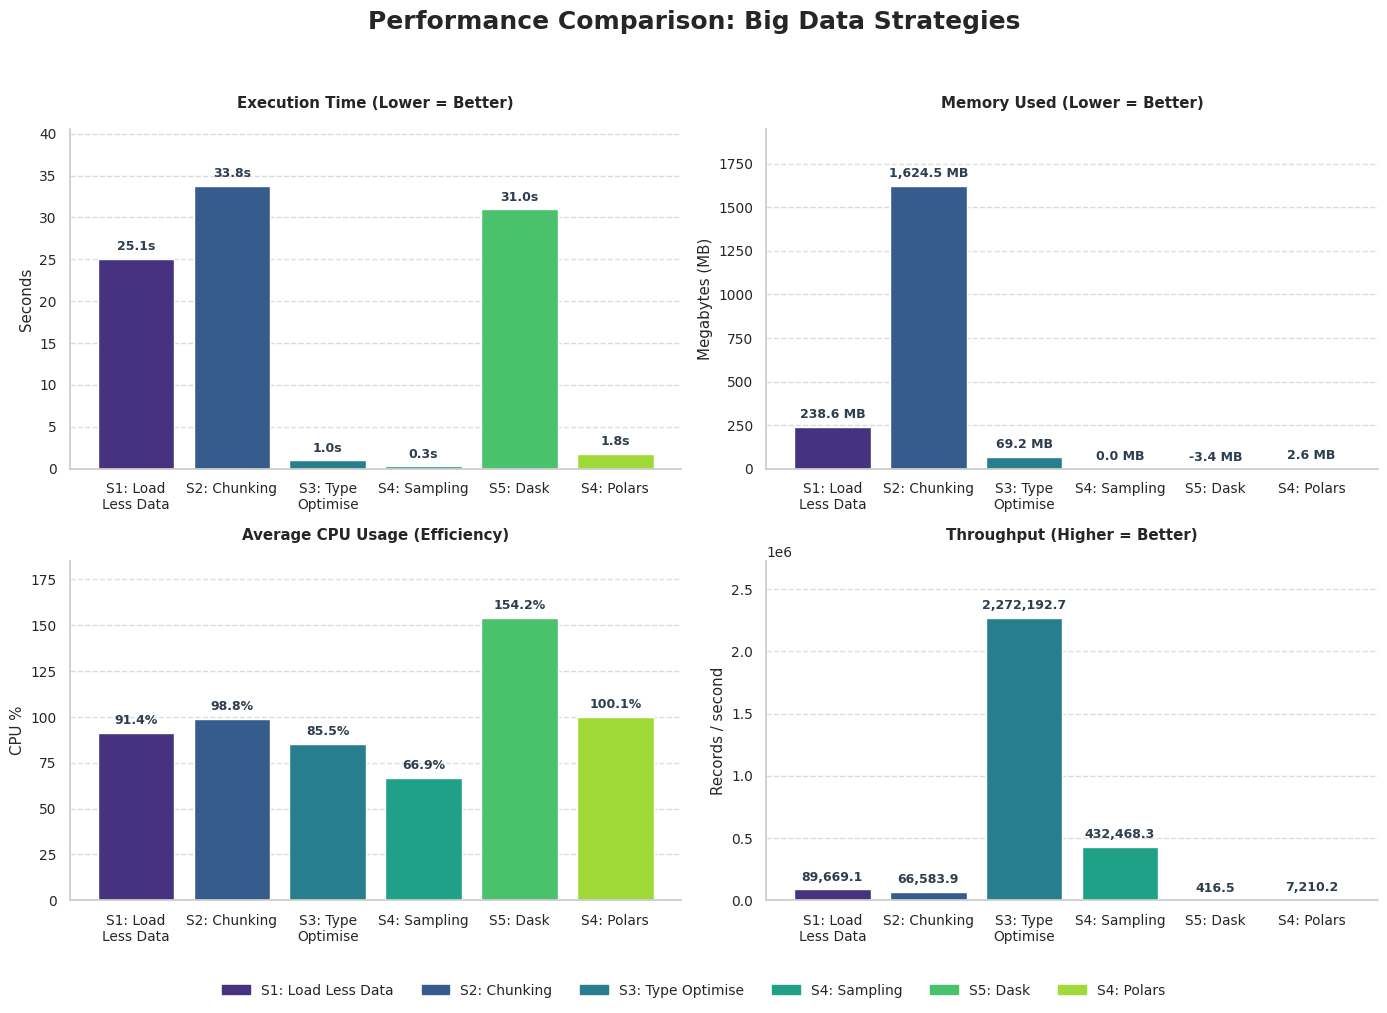

Saved: chart_all_strategies.png


In [47]:
# PART A — CHART: ALL 5 STRATEGIES COMPARISON

# Apply a clean, modern theme immediately
sns.set_theme(style="whitegrid", font_scale=0.9)

# Build the comparison table
all_strategies = pd.DataFrame([
    performance_less_data,
    performance_chunking,
    performance_opt,
    performance_sampling,
    performance_dask,
    performance_polars,
])

# Short labels for the x-axis (Updated to S1-S6)
all_strategies["Label"] = [
    "S1: Load\nLess Data",
    "S2: Chunking",
    "S3: Type\nOptimise",
    "S4: Sampling",
    "S5: Dask",
    "S4: Polars",
]

# --- Visualization Setup ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Performance Comparison: Big Data Strategies", fontsize=18, fontweight="bold", y=0.98)

# Modern color palette
colors = sns.color_palette("viridis", len(all_strategies))

labels       = all_strategies["Label"].tolist()
exec_times   = all_strategies["Execution Time (s)"].tolist()
memory_vals  = all_strategies["Memory Used (MB)"].tolist()
cpu_vals     = all_strategies["Average CPU (%)"].tolist()
throughputs  = all_strategies["Throughput (records/sec)"].tolist()

# Helper: write the value on top of each bar
def add_labels(ax, values, unit=""):
    max_val = max([v for v in values if v is not None]) if any(v is not None for v in values) else 1
    for bar, val in zip(ax.patches, values):
        if val is None or (isinstance(val, float) and val != val):
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (max_val * 0.02),
            f"{val:,.1f}{unit}" if isinstance(val, float) else f"{val}{unit}",
            ha="center", va="bottom", fontsize=9, fontweight="bold", color="#2c3e50"
        )

# Panel 1 — Execution Time
axes[0, 0].bar(labels, exec_times, color=colors, edgecolor="white", linewidth=1)
add_labels(axes[0, 0], exec_times, "s")
axes[0, 0].set_title("Execution Time (Lower = Better)", fontweight="bold", pad=15)
axes[0, 0].set_ylabel("Seconds")
axes[0, 0].set_ylim(0, max(exec_times) * 1.2)

# Panel 2 — Memory Used
axes[0, 1].bar(labels, memory_vals, color=colors, edgecolor="white", linewidth=1)
add_labels(axes[0, 1], memory_vals, " MB")
axes[0, 1].set_title("Memory Used (Lower = Better)", fontweight="bold", pad=15)
axes[0, 1].set_ylabel("Megabytes (MB)")
axes[0, 1].set_ylim(0, max(memory_vals) * 1.2)

# Panel 3 — Average CPU %
axes[1, 0].bar(labels, cpu_vals, color=colors, edgecolor="white", linewidth=1)
add_labels(axes[1, 0], cpu_vals, "%")
axes[1, 0].set_title("Average CPU Usage (Efficiency)", fontweight="bold", pad=15)
axes[1, 0].set_ylabel("CPU %")
axes[1, 0].set_ylim(0, max(cpu_vals) * 1.2)

# Panel 4 — Throughput
throughputs_clean = [v if v is not None else 0 for v in throughputs]
axes[1, 1].bar(labels, throughputs_clean, color=colors, edgecolor="white", linewidth=1)
add_labels(axes[1, 1], throughputs_clean, "")
axes[1, 1].set_title("Throughput (Higher = Better)", fontweight="bold", pad=15)
axes[1, 1].set_ylabel("Records / second")
axes[1, 1].set_ylim(0, max(throughputs_clean) * 1.2)

# Clean up spines and add horizontal grids for readability
for ax in axes.flat:
    sns.despine(ax=ax)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.xaxis.grid(False)

# Import Patch from matplotlib.patches
from matplotlib.patches import Patch

# Legend at the bottom
legend_items = [Patch(color=colors[i], label=labels[i].replace("\n", " "))
                for i in range(len(labels))]
fig.legend(handles=legend_items, loc="lower center", ncol=6,
           fontsize=10, bbox_to_anchor=(0.5, -0.02), frameon=False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("chart_all_strategies.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: chart_all_strategies.png")

### **5.1 Comparison between Libraries (Pandas vs. Dask vs. Polars)**

In [51]:
# PART B — FULL LOAD COMPARISON: Pandas vs Dask vs Polars

import tracemalloc

# Helper: run a load+process function 3 times and return averaged metrics
def measure_library(load_func, process_func, file_path, runs=3):
    load_times    = []
    process_times = []
    total_times   = []
    peak_mems     = []

    for i in range(runs):
        gc.collect()  # clear memory before each run so measurements are clean

        # --- Memory snapshot BEFORE ---
        tracemalloc.start()

        # --- Loading time ---
        t0   = time.time()
        data = load_func(file_path)
        t1   = time.time()

        # --- Processing time ---
        t2     = time.time()
        result = process_func(data)
        t3     = time.time()

        # --- Memory snapshot AFTER (peak) ---
        peak_mem = tracemalloc.get_traced_memory()[1] / 1024 / 1024
        tracemalloc.stop()

        load_times.append(round(t1 - t0, 4))
        process_times.append(round(t3 - t2, 4))
        total_times.append(round(t3 - t0, 4))
        peak_mems.append(round(peak_mem, 2))

        del data, result
        gc.collect()

    return {
        "Avg Load Time (s)"    : round(sum(load_times)    / runs, 4),
        "Avg Process Time (s)" : round(sum(process_times) / runs, 4),
        "Avg Total Time (s)"   : round(sum(total_times)   / runs, 4),
        "Peak Memory (MB)"     : round(sum(peak_mems)     / runs, 2),
        "All Load Times"       : load_times,       # kept for transparency
        "All Process Times"    : process_times,
        "All Total Times"      : total_times,
    }


# ── Pandas ──────────────────────────────────────────────────

def pandas_load(file_path):
    return pd.read_csv(file_path, low_memory=False)

def pandas_process(data):
    return (data
            .groupby("PRODUCT_TYPE_ID")["PRODUCT_LENGTH"]
            .mean()
            .reset_index()
            .sort_values("PRODUCT_LENGTH", ascending=False))

print("Running Pandas (3 runs)...")
metrics_pandas = measure_library(pandas_load, pandas_process, "product_amazon_data.csv")
print(f"  Load: {metrics_pandas['Avg Load Time (s)']}s | "
      f"Process: {metrics_pandas['Avg Process Time (s)']}s | "
      f"Total: {metrics_pandas['Avg Total Time (s)']}s | "
      f"Memory: {metrics_pandas['Peak Memory (MB)']} MB")


# ── Dask ────────────────────────────────────────────────────

def dask_load(file_path):
    return dd.read_csv(file_path, low_memory=False, assume_missing=True)

def dask_process(data):
    return (data
            .groupby("PRODUCT_TYPE_ID")["PRODUCT_LENGTH"]
            .mean()
            .reset_index()
            .compute()
            .sort_values("PRODUCT_LENGTH", ascending=False))

print("Running Dask (3 runs)...")
metrics_dask = measure_library(dask_load, dask_process, "product_amazon_data.csv")
print(f"  Load: {metrics_dask['Avg Load Time (s)']}s | "
      f"Process: {metrics_dask['Avg Process Time (s)']}s | "
      f"Total: {metrics_dask['Avg Total Time (s)']}s | "
      f"Memory: {metrics_dask['Peak Memory (MB)']} MB")


# ── Polars ──────────────────────────────────────────────────

def polars_load(file_path):
    return pl.scan_csv(file_path, infer_schema_length=10000)

def polars_process(data):
    return (data
            .group_by("PRODUCT_TYPE_ID")
            .agg(pl.col("PRODUCT_LENGTH").mean().alias("PRODUCT_LENGTH"))
            .sort("PRODUCT_LENGTH", descending=True)
            .collect()
            .to_pandas())

print("Running Polars (3 runs)...")
metrics_polars = measure_library(polars_load, polars_process, "product_amazon_data.csv")
print(f"  Load: {metrics_polars['Avg Load Time (s)']}s | "
      f"Process: {metrics_polars['Avg Process Time (s)']}s | "
      f"Total: {metrics_polars['Avg Total Time (s)']}s | "
      f"Memory: {metrics_polars['Peak Memory (MB)']} MB")

Running Pandas (3 runs)...
  Load: 44.7357s | Process: 0.1418s | Total: 44.8775s | Memory: 1819.91 MB
Running Dask (3 runs)...
  Load: 0.1572s | Process: 42.354s | Total: 42.5112s | Memory: 430.94 MB
Running Polars (3 runs)...
  Load: 0.0208s | Process: 1.3302s | Total: 1.351s | Memory: 0.01 MB


In [49]:
library_table = pd.DataFrame({
    "Library"              : ["Pandas", "Dask", "Polars"],
    "Avg Load Time (s)"    : [metrics_pandas["Avg Load Time (s)"],
                              metrics_dask["Avg Load Time (s)"],
                              metrics_polars["Avg Load Time (s)"]],
    "Avg Process Time (s)" : [metrics_pandas["Avg Process Time (s)"],
                              metrics_dask["Avg Process Time (s)"],
                              metrics_polars["Avg Process Time (s)"]],
    "Avg Total Time (s)"   : [metrics_pandas["Avg Total Time (s)"],
                              metrics_dask["Avg Total Time (s)"],
                              metrics_polars["Avg Total Time (s)"]],
    "Peak Memory (MB)"     : [metrics_pandas["Peak Memory (MB)"],
                              metrics_dask["Peak Memory (MB)"],
                              metrics_polars["Peak Memory (MB)"]],
})

print("=== Library Comparison Table (Average of 3 Runs) ===")
display(library_table)

print("\nIndividual run times (Load / Process / Total) in seconds:")
for lib, metrics in [("Pandas", metrics_pandas),
                     ("Dask",   metrics_dask),
                     ("Polars", metrics_polars)]:
    for i in range(3):
        print(f"  {lib} Run {i+1}: "
              f"Load={metrics['All Load Times'][i]}s | "
              f"Process={metrics['All Process Times'][i]}s | "
              f"Total={metrics['All Total Times'][i]}s")
    print()

=== Library Comparison Table (Average of 3 Runs) ===


,Library,Avg Load Time (s),Avg Process Time (s),Avg Total Time (s),Peak Memory (MB)
0,Pandas,43.6315,0.1321,43.7636,1819.90
1,Dask,0.1497,45.9666,46.1163,431.51
2,Polars,0.0213,1.0671,1.0885,0.01



Individual run times (Load / Process / Total) in seconds:
  Pandas Run 1: Load=43.1085s | Process=0.1217s | Total=43.2302s
  Pandas Run 2: Load=44.406s | Process=0.146s | Total=44.552s
  Pandas Run 3: Load=43.38s | Process=0.1286s | Total=43.5087s

  Dask Run 1: Load=0.246s | Process=52.5794s | Total=52.8255s
  Dask Run 2: Load=0.0944s | Process=42.7867s | Total=42.8811s
  Dask Run 3: Load=0.1087s | Process=42.5336s | Total=42.6423s

  Polars Run 1: Load=0.0632s | Process=1.2377s | Total=1.3009s
  Polars Run 2: Load=0.0004s | Process=0.997s | Total=0.9974s
  Polars Run 3: Load=0.0004s | Process=0.9666s | Total=0.9671s



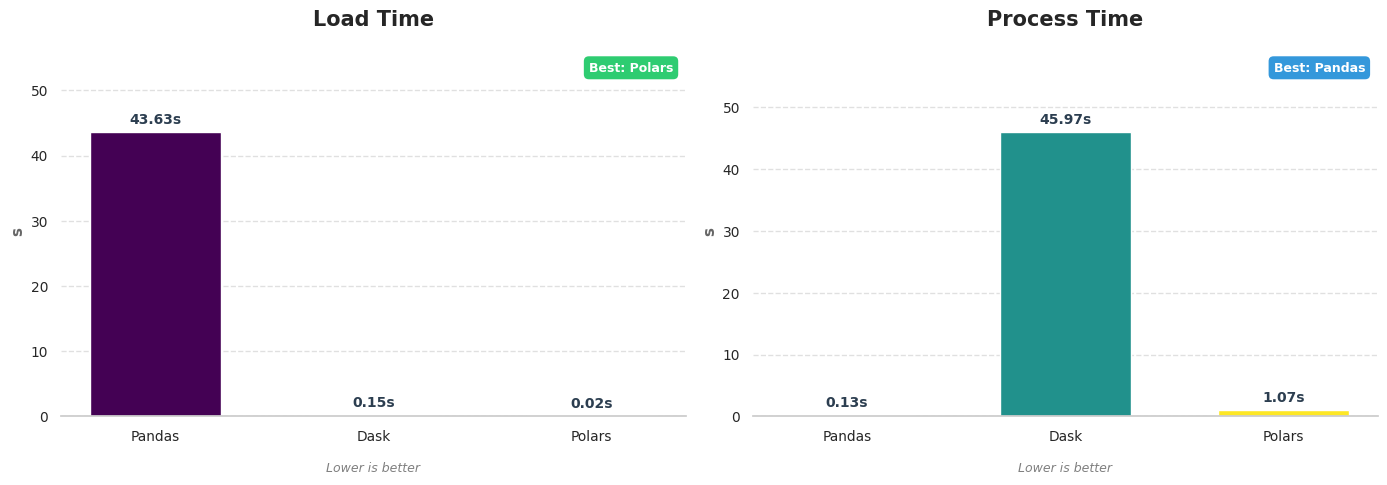

Saved: library_comparison_row_1.png


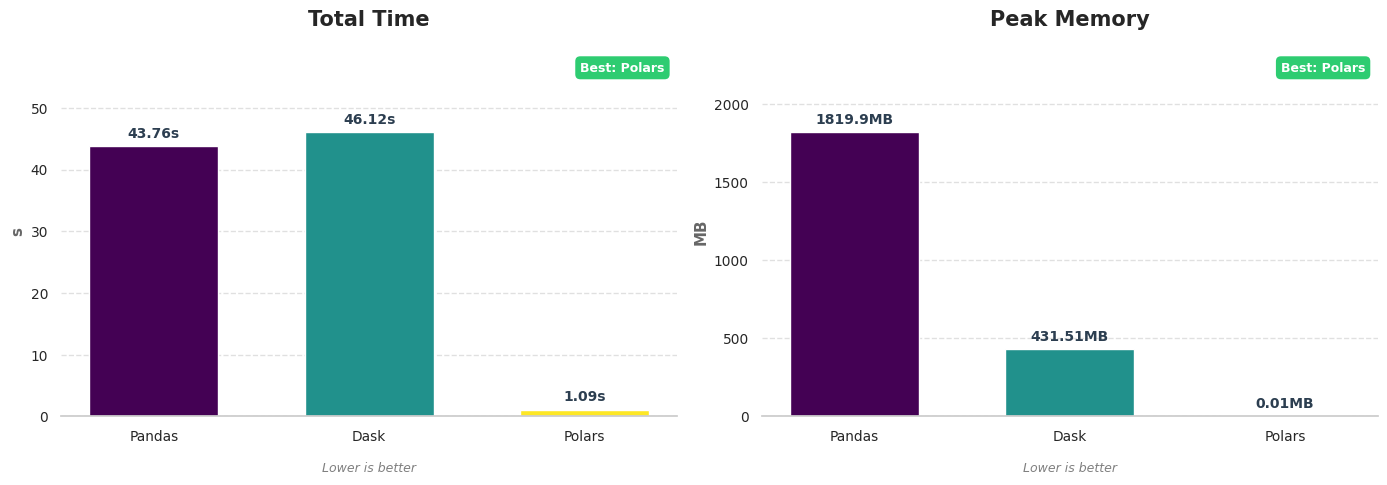

Saved: library_comparison_row_2.png


In [50]:
# CHART — LIBRARY COMPARISON: Pandas vs Dask vs Polars

sns.set_theme(style="whitegrid", font_scale=0.9)

lib_labels = ["Pandas", "Dask", "Polars"]
lib_colors = ["#440154", "#21918c", "#fde725"]

lib_total   = [metrics_pandas["Avg Total Time (s)"],
               metrics_dask["Avg Total Time (s)"],
               metrics_polars["Avg Total Time (s)"]]

lib_load    = [metrics_pandas["Avg Load Time (s)"],
               metrics_dask["Avg Load Time (s)"],
               metrics_polars["Avg Load Time (s)"]]

lib_process = [metrics_pandas["Avg Process Time (s)"],
               metrics_dask["Avg Process Time (s)"],
               metrics_polars["Avg Process Time (s)"]]

lib_memory  = [metrics_pandas["Peak Memory (MB)"],
               metrics_dask["Peak Memory (MB)"],
               metrics_polars["Peak Memory (MB)"]]

# Organise into pairs for the 2-column layout
# Each tuple: (Title, Data, Unit, Highlight Color)
chart_pairs = [
    [("Load Time", lib_load, "s", "#2ecc71"), ("Process Time", lib_process, "s", "#3498db")],
    [("Total Time", lib_total, "s", "#2ecc71"), ("Peak Memory", lib_memory, "MB", "#2ecc71")]
]

# 3. PLOTTING IN ROWS
for row_idx, pair in enumerate(chart_pairs):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # Creates 1 row with 2 charts

    for i, (title, data, unit, best_color) in enumerate(pair):
        ax = axes[i]

        # Draw bars
        bars = ax.bar(lib_labels, data, color=lib_colors, edgecolor="white", linewidth=1, width=0.6)

        # Add number labels on top
        max_val = max(data) if data else 1
        for bar, val in zip(ax.patches, data):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max_val * 0.02,
                f"{round(val, 2)}{unit}",
                ha="center", va="bottom", fontsize=10, fontweight="bold", color="#2c3e50"
            )

        # Add the "Best" badge
        best_idx = data.index(min(data))
        ax.text(0.98, 0.96, f"Best: {lib_labels[best_idx]}",
                transform=ax.transAxes, ha="right", va="top", fontsize=9, fontweight="bold",
                color="white", bbox=dict(boxstyle="round,pad=0.4", facecolor=best_color, edgecolor="none"))

        # Styling titles and labels
        ax.set_title(title, fontsize=15, fontweight="bold", pad=15)
        ax.set_ylabel(unit, fontweight="bold", alpha=0.7)
        ax.set_ylim(0, max(data) * 1.3)

        # Caption
        ax.text(0.5, -0.15, "Lower is better", transform=ax.transAxes,
                ha="center", fontsize=9, color="gray", style='italic')

        # Clean up axes
        sns.despine(ax=ax, left=True)
        ax.yaxis.grid(True, linestyle='--', alpha=0.6)
        ax.xaxis.grid(False)

    plt.tight_layout()
    filename = f"library_comparison_row_{row_idx+1}.png"
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {filename}")

## **Comparison Analysis**

### **Discussion**

**Why Polars is fastest:** Polars uses lazy evaluation — it builds a query plan first and only reads the data it needs when .collect() is called. It is also built in Rust with multi-threading by default, using all CPU cores automatically. Combined with columnar Arrow memory storage, this makes both loading and processing significantly faster than the other libraries.

**Why Pandas is slowest:** Pandas loads the entire file into memory at once and runs on a single thread. It cannot take advantage of multiple CPU cores, which becomes a clear bottleneck on large datasets. That said, Pandas remains the easiest to use and has the widest ecosystem support, making it a reasonable choice for smaller data.

**Why Dask falls in between:** Dask is designed for data that is too large to fit in RAM, splitting work into chunks processed in parallel. However, this coordination has overhead. Since the Amazon dataset fits in memory, Dask's chunking mechanism adds cost rather than benefit which makes it slower than Polars and only marginally better than Pandas here.

**Trade-off:** The core trade-off is performance vs simplicity. Polars wins on speed and memory efficiency, Pandas wins on ease of use and ecosystem, and Dask is best suited for truly out-of-memory workloads — not for datasets like this one.
